<a href="https://colab.research.google.com/github/Mehaha-sys/data-ml-portfolio/blob/main/Video_Game_Commercial_Performance_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
import pandas as pd

PROJECT_DIR = "/content/drive/MyDrive/Video_Game_Analytics"

RAW_FILE = os.path.join(
    PROJECT_DIR,
    "completed_records_plus_sentiment_metrics.csv"
)

print(RAW_FILE)

/content/drive/MyDrive/Video_Game_Analytics/completed_records_plus_sentiment_metrics.csv


In [ ]:
df_raw = pd.read_csv(RAW_FILE)

print("Raw dataset loaded.")
print("Shape:", df_raw.shape)

Raw dataset loaded.
Shape: (3001, 45)


In [ ]:
df = df_raw.copy()

print("Working copy created.")
print("Shape:", df.shape)

Working copy created.
Shape: (3001, 45)


In [ ]:
# Basic dataset overview

print("Shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

print("\nData types:")
print(df.dtypes)

Shape: (3001, 45)

Columns:
1. game_title
2. user_review_count
3. critic_review_count
4. developer
5. platforms
6. platform_count
7. Avg_Rank
8. Year
9. Genre
10. Publisher
11. NA_Sales
12. EU_Sales
13. JP_Sales
14. Other_Sales
15. Total_Sales
16. metascore
17. Difficulty_Easy
18. Difficulty_Just_Right
19. Difficulty_Simple
20. Difficulty_Tough
21. Difficulty_Unforgiving
22. Play Time_<_1_Hour
23. Play Time_>=_80_Hours
24. Play Time_~1_Hour
25. Play Time_~12_Hours
26. Play Time_~2_Hours
27. Play Time_~20_Hours
28. Play Time_~4_Hours
29. Play Time_~40_Hours
30. Play Time_~60_Hours
31. Play Time_~8_Hours
32. Completion_Beat_It
33. Completion_Conquered_It
34. Completion_Halfway
35. Completion_Played_It
36. Completion_Tried_It
37. vader_sentiment_mean
38. textblob_sentiment_mean
39. hf_sentiment_mean
40. global_user_score_mean
41. user_score_mean
42. composite_sentiment_correlation_user_mean
43. composite_sentiment_correlation_global_mean
44. composite_sentiment_confidence_mean
45. composi

In [ ]:
# Missing values

missing = pd.DataFrame({
    "missing": df.isna().sum(),
    "missing_%": (df.isna().mean() * 100).round(2)
})

display(missing)

,missing,missing_%
game_title,0,0.0
user_review_count,0,0.0
critic_review_count,0,0.0
developer,0,0.0
platforms,0,0.0
platform_count,0,0.0
Avg_Rank,0,0.0
Year,0,0.0
Genre,0,0.0
Publisher,0,0.0


In [ ]:
# Duplicates

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
# First few records

display(df.head())

,game_title,user_review_count,critic_review_count,developer,platforms,platform_count,Avg_Rank,Year,Genre,Publisher,...,Completion_Tried_It,vader_sentiment_mean,textblob_sentiment_mean,hf_sentiment_mean,global_user_score_mean,user_score_mean,composite_sentiment_correlation_user_mean,composite_sentiment_correlation_global_mean,composite_sentiment_confidence_mean,composite_sentiment_adaptive_mean
0,007: quantum of solace,76.0,69.0,Treyarch,"wii, playstation-3, xbox-360, pc, playstation-2",5.0,5737.83,2008,Action,Activision,...,13.40,0.438,0.082,-0.019,6.669,6.592,0.159,0.140,0.142,0.172
1,100 classic books,11.0,7.0,Genius Sonority Inc.,ds,1.0,3008.00,2008,Misc,Nintendo,...,37.78,0.531,-0.021,0.332,6.100,9.333,0.281,0.266,0.192,0.301
2,101-in-1 explosive megamix,4.0,13.0,Nordcurrent,"wii, ds",2.0,7712.00,2008,Puzzle,Nordcurrent,...,17.07,-0.081,-0.028,-0.015,3.717,5.667,-0.040,-0.037,-0.026,-0.012
3,1701 a.d.,26.0,30.0,Related Designs,pc,1.0,5843.00,2006,Simulation,Deep Silver,...,10.71,0.595,0.066,0.001,8.200,6.500,0.212,0.185,0.143,0.094
4,18 wheeler: american pro trucker,5.0,17.0,Acclaim Studios Cheltenham,"playstation-2, gamecube, dreamcast",3.0,7454.50,2001,Racing,Acclaim Entertainment,...,22.06,0.467,0.039,-0.598,4.467,5.667,-0.051,-0.090,-0.045,-0.099


In [ ]:
print("Unique games:", df["game_title"].nunique())
print("Unique developers:", df["developer"].nunique())
print("Unique publishers:", df["Publisher"].nunique())
print("Unique genres:", df["Genre"].nunique())
print("Years:", df["Year"].min(), "to", df["Year"].max())

Unique games: 3001
Unique developers: 815
Unique publishers: 169
Unique genres: 12
Years: 2001 to 2016


In [ ]:
print(df["Genre"].value_counts())

Genre
Action          657
Role-Playing    446
Shooter         365
Sports          242
Racing          228
Platform        204
Fighting        177
Misc            175
Strategy        156
Adventure       141
Simulation      139
Puzzle           71
Name: count, dtype: int64


In [ ]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
user_review_count,3001.0,321.711096,1095.462139,0.000,16.000,51.000,173.000,26520.000
critic_review_count,3001.0,39.278241,20.861357,0.000,23.000,36.000,52.000,133.000
platform_count,3001.0,2.053316,1.408719,1.000,1.000,1.000,3.000,9.000
Avg_Rank,3001.0,6162.047058,3924.607051,1.000,2911.000,5779.250,9046.000,16568.000
Year,3001.0,2007.493502,4.059069,2001.000,2004.000,2007.000,2011.000,2016.000
NA_Sales,3001.0,0.819087,1.733874,0.000,0.100,0.280,0.840,41.490
EU_Sales,3001.0,0.502982,1.281451,0.000,0.040,0.130,0.450,29.020
JP_Sales,3001.0,0.128517,0.402785,0.000,0.000,0.000,0.090,6.500
Other_Sales,3001.0,0.180956,0.480191,0.000,0.010,0.050,0.170,10.720
Total_Sales,3001.0,1.631543,3.486469,0.010,0.230,0.600,1.650,82.740


In [ ]:
for col in ["Genre", "Publisher", "developer", "platforms"]:
    print(f"\n--- {col} ---")
    print("Unique:", df[col].nunique())
    print(df[col].value_counts().head(10))


--- Genre ---
Unique: 12
Genre
Action          657
Role-Playing    446
Shooter         365
Sports          242
Racing          228
Platform        204
Fighting        177
Misc            175
Strategy        156
Adventure       141
Name: count, dtype: int64

--- Publisher ---
Unique: 169
Publisher
Electronic Arts                 279
Nintendo                        263
Sony                            213
Ubisoft                         180
Sega                            145
Activision                      144
Namco Bandai Games              137
THQ                             125
Konami Digital Entertainment    118
Microsoft                       109
Name: count, dtype: int64

--- developer ---
Unique: 815
developer
Capcom              67
Nintendo            56
Konami              36
EA Sports           35
Omega Force         35
EA Canada           33
Namco               31
Ubisoft             30
Ubisoft Montreal    27
EA Tiburon          26
Name: count, dtype: int64

--- platforms ---

In [ ]:
numeric_corr = df.select_dtypes(include="number").corr()

display(
    numeric_corr["Total_Sales"]
    .sort_values(ascending=False)
    .to_frame("Correlation_with_Total_Sales")
)

,Correlation_with_Total_Sales
Total_Sales,1.000000
NA_Sales,0.956448
EU_Sales,0.942507
Other_Sales,0.868177
JP_Sales,0.505087
user_review_count,0.338386
critic_review_count,0.308210
metascore,0.260370
platform_count,0.254788
Difficulty_Just_Right,0.096909


In [ ]:
import sqlite3

conn = sqlite3.connect(":memory:")

df.to_sql(
    "games",
    conn,
    index=False,
    if_exists="replace"
)

print("Loaded:", pd.read_sql("SELECT COUNT(*) AS games FROM games", conn))

Loaded:    games
0   3001


In [ ]:
query = """
SELECT
    game_title,
    Genre,
    Year,
    Total_Sales,
    metascore,
    user_score_mean,
    user_review_count,
    platform_count
FROM games
LIMIT 10;
"""

display(pd.read_sql(query, conn))

,game_title,Genre,Year,Total_Sales,metascore,user_score_mean,user_review_count,platform_count
0,007: quantum of solace,Action,2008,3.91,65,6.592,76.0,5.0
1,100 classic books,Misc,2008,0.67,70,9.333,11.0,1.0
2,101-in-1 explosive megamix,Puzzle,2008,0.20,46,5.667,4.0,2.0
3,1701 a.d.,Simulation,2006,0.30,79,6.500,26.0,1.0
4,18 wheeler: american pro trucker,Racing,2001,0.51,52,5.667,5.0,3.0
5,2002 fifa world cup,Sports,2002,0.84,73,7.333,14.0,5.0
6,2010 fifa world cup south africa,Sports,2010,3.00,83,8.040,52.0,4.0
7,2014 fifa world cup brazil,Sports,2014,1.17,73,4.458,119.0,2.0
8,24: the game,Adventure,2006,0.31,62,7.364,28.0,1.0
9,25 to life,Shooter,2006,0.59,39,4.875,24.0,2.0


In [ ]:
query = """
SELECT
    game_title,
    user_review_count,
    Total_Sales
FROM games
ORDER BY user_review_count DESC
LIMIT 20;
"""

display(pd.read_sql(query, conn))

,game_title,user_review_count,Total_Sales
0,god of war,26520.0,4.45
1,uncharted 4: a thief's end,17179.0,4.20
2,the witcher 3: wild hunt,16026.0,5.64
3,the last of us,15494.0,10.52
4,bloodborne,12836.0,2.38
5,grand theft auto v,11701.0,55.92
6,bioshock infinite,10590.0,4.38
7,diablo iii,10384.0,11.06
8,half-life 2,9421.0,2.99
9,call of duty: modern warfare 3,9190.0,30.84


In [ ]:
query = """
SELECT
    metascore,
    Total_Sales
FROM games
ORDER BY metascore DESC;
"""

display(pd.read_sql(query, conn))

,metascore,Total_Sales
0,98,22.49
1,97,13.11
2,97,55.92
3,97,6.47
4,97,2.82
...,...,...
2996,27,0.54
2997,25,0.12
2998,25,2.52
2999,23,0.20


In [ ]:
query = """
SELECT
    platform_count,
    COUNT(*) AS games,
    AVG(Total_Sales) AS avg_sales
FROM games
GROUP BY platform_count
ORDER BY platform_count;
"""

display(pd.read_sql(query, conn))

,platform_count,games,avg_sales
0,1.0,1517,1.167574
1,2.0,582,1.178402
2,3.0,483,2.013188
3,4.0,227,2.527181
4,5.0,93,3.556989
5,6.0,54,5.068519
6,7.0,29,6.591379
7,8.0,12,4.914167
8,9.0,4,9.640000


In [ ]:
query = """
SELECT
    Genre,
    COUNT(*) AS games,
    AVG(Total_Sales) AS avg_sales,
    AVG(metascore) AS avg_metascore,
    AVG(user_score_mean) AS avg_user_score
FROM games
GROUP BY Genre
ORDER BY avg_sales DESC;
"""

display(pd.read_sql(query, conn))

,Genre,games,avg_sales,avg_metascore,avg_user_score
0,Sports,242,3.161694,77.768595,7.299905
1,Misc,175,2.163886,69.491429,7.271114
2,Shooter,365,2.093945,72.956164,7.040233
3,Platform,204,1.791863,74.240196,7.657328
4,Racing,228,1.786623,72.609649,7.190000
5,Action,657,1.773805,69.351598,7.081516
6,Simulation,139,1.248705,72.503597,7.432655
7,Fighting,177,1.220734,71.197740,7.273938
8,Puzzle,71,1.092676,74.901408,7.307732
9,Role-Playing,446,0.988946,73.417040,7.510265


In [ ]:
# Small ML scouting experiment:
# Which game attributes are most useful for predicting Total_Sales?

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import pandas as pd

# Keep the feature set deliberately small
features = [
    "user_review_count",
    "critic_review_count",
    "metascore",
    "platform_count",
    "Year",
    "Genre"
]

target = "Total_Sales"

X = df[features].copy()
y = df[target].copy()

# Genre is categorical; the rest are numeric
preprocessor = ColumnTransformer(
    transformers=[
        ("genre", OneHotEncoder(handle_unknown="ignore"), ["Genre"])
    ],
    remainder="passthrough"
)

X_processed = preprocessor.fit_transform(X)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed,
    y,
    test_size=0.2,
    random_state=42
)

# One simple model — no tuning
model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

# Basic performance check
predictions = model.predict(X_test)

print("R²:", round(r2_score(y_test, predictions), 3))
print("MAE:", round(mean_absolute_error(y_test, predictions), 3))

# Recover feature names
feature_names = preprocessor.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop feature importances:")
display(importance.head(15))

R²: 0.206
MAE: 1.282

Top feature importances:


,Feature,Importance
12,remainder__user_review_count,0.375786
14,remainder__metascore,0.155978
15,remainder__platform_count,0.154153
13,remainder__critic_review_count,0.116972
16,remainder__Year,0.082350
10,genre__Genre_Sports,0.025788
4,genre__Genre_Platform,0.018092
3,genre__Genre_Misc,0.016479
8,genre__Genre_Shooter,0.013215
0,genre__Genre_Action,0.010914


In [ ]:
query = """
SELECT
    CASE
        WHEN user_review_count < 10 THEN '<10 reviews'
        WHEN user_review_count < 50 THEN '10–49 reviews'
        WHEN user_review_count < 200 THEN '50–199 reviews'
        WHEN user_review_count < 1000 THEN '200–999 reviews'
        WHEN user_review_count < 5000 THEN '1,000–4,999 reviews'
        ELSE '5,000+ reviews'
    END AS engagement_band,

    COUNT(*) AS games,
    ROUND(AVG(Total_Sales), 3) AS avg_sales,
    ROUND(AVG(user_review_count), 1) AS avg_reviews,
    ROUND(AVG(metascore), 2) AS avg_metascore

FROM games

GROUP BY engagement_band

ORDER BY
    CASE engagement_band
        WHEN '<10 reviews' THEN 1
        WHEN '10–49 reviews' THEN 2
        WHEN '50–199 reviews' THEN 3
        WHEN '200–999 reviews' THEN 4
        WHEN '1,000–4,999 reviews' THEN 5
        WHEN '5,000+ reviews' THEN 6
    END;
"""

display(pd.read_sql(query, conn))

,engagement_band,games,avg_sales,avg_reviews,avg_metascore
0,<10 reviews,434,0.612,4.9,63.32
1,10–49 reviews,1047,0.880,24.1,68.75
2,50–199 reviews,826,1.508,102.2,74.55
3,200–999 reviews,464,2.554,452.7,79.42
4,"1,000–4,999 reviews",203,4.973,1972.6,85.12
5,"5,000+ reviews",27,9.957,9005.8,89.93


In [ ]:
query = """
SELECT
    CASE
        WHEN metascore < 60 THEN 'Low (<60)'
        WHEN metascore < 75 THEN 'Mid (60–74)'
        WHEN metascore < 85 THEN 'High (75–84)'
        ELSE 'Very High (85+)'
    END AS score_band,

    CASE
        WHEN user_review_count < 50 THEN 'Low engagement (<50)'
        WHEN user_review_count < 200 THEN 'Medium (50–199)'
        WHEN user_review_count < 1000 THEN 'High (200–999)'
        ELSE 'Very High (1000+)'
    END AS engagement_band,

    COUNT(*) AS games,
    ROUND(AVG(Total_Sales), 3) AS avg_sales

FROM games

GROUP BY score_band, engagement_band

ORDER BY
    CASE score_band
        WHEN 'Low (<60)' THEN 1
        WHEN 'Mid (60–74)' THEN 2
        WHEN 'High (75–84)' THEN 3
        WHEN 'Very High (85+)' THEN 4
    END,
    CASE engagement_band
        WHEN 'Low engagement (<50)' THEN 1
        WHEN 'Medium (50–199)' THEN 2
        WHEN 'High (200–999)' THEN 3
        WHEN 'Very High (1000+)' THEN 4
    END;
"""

display(pd.read_sql(query, conn))

,score_band,engagement_band,games,avg_sales
0,Low (<60),Low engagement (<50),376,0.519
1,Low (<60),Medium (50–199),74,1.132
2,Low (<60),High (200–999),22,0.987
3,Low (<60),Very High (1000+),2,0.880
4,Mid (60–74),Low engagement (<50),668,0.741
5,Mid (60–74),Medium (50–199),279,1.352
6,Mid (60–74),High (200–999),79,1.760
7,Mid (60–74),Very High (1000+),16,2.467
8,High (75–84),Low engagement (<50),361,1.002
9,High (75–84),Medium (50–199),345,1.495


In [ ]:
query = """
SELECT
    CASE
        WHEN user_review_count < 50 THEN 'Low engagement (<50)'
        WHEN user_review_count < 200 THEN 'Medium (50–199)'
        WHEN user_review_count < 1000 THEN 'High (200–999)'
        ELSE 'Very High (1000+)'
    END AS engagement_band,

    platform_count,

    COUNT(*) AS games,
    ROUND(AVG(Total_Sales), 3) AS avg_sales

FROM games

GROUP BY engagement_band, platform_count

ORDER BY
    CASE engagement_band
        WHEN 'Low engagement (<50)' THEN 1
        WHEN 'Medium (50–199)' THEN 2
        WHEN 'High (200–999)' THEN 3
        WHEN 'Very High (1000+)' THEN 4
    END,
    platform_count;
"""

platform_engagement = pd.read_sql(query, conn)

display(platform_engagement)

,engagement_band,platform_count,games,avg_sales
0,Low engagement (<50),1.0,806,0.544
1,Low engagement (<50),2.0,296,0.693
2,Low engagement (<50),3.0,200,1.103
3,Low engagement (<50),4.0,122,1.690
4,Low engagement (<50),5.0,36,1.866
5,Low engagement (<50),6.0,13,2.190
6,Low engagement (<50),7.0,6,1.680
7,Low engagement (<50),8.0,2,5.585
8,Medium (50–199),1.0,398,1.112
9,Medium (50–199),2.0,177,1.112


In [ ]:
query = """
SELECT
    platform_count,
    COUNT(*) AS games,
    ROUND(AVG(Total_Sales), 3) AS avg_sales,
    ROUND(AVG(user_review_count), 1) AS avg_reviews,
    ROUND(AVG(metascore), 2) AS avg_metascore

FROM games

GROUP BY platform_count

ORDER BY platform_count;
"""

platform_summary = pd.read_sql(query, conn)

display(platform_summary)

,platform_count,games,avg_sales,avg_reviews,avg_metascore
0,1.0,1517,1.168,261.0,72.09
1,2.0,582,1.178,252.3,72.28
2,3.0,483,2.013,484.2,72.57
3,4.0,227,2.527,399.9,73.36
4,5.0,93,3.557,453.3,73.92
5,6.0,54,5.069,489.3,77.35
6,7.0,29,6.591,598.6,75.03
7,8.0,12,4.914,234.6,76.67
8,9.0,4,9.640,2321.8,82.25


In [ ]:
query = """
SELECT
    platform_count,
    COUNT(*) AS games
FROM games
GROUP BY platform_count
ORDER BY platform_count;
"""

display(pd.read_sql(query, conn))

,platform_count,games
0,1.0,1517
1,2.0,582
2,3.0,483
3,4.0,227
4,5.0,93
5,6.0,54
6,7.0,29
7,8.0,12
8,9.0,4


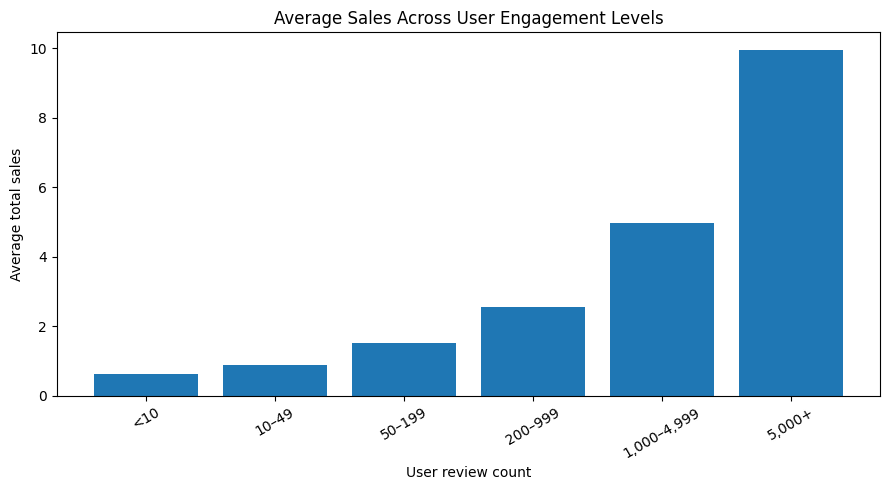

In [ ]:
import matplotlib.pyplot as plt

query = """
SELECT
    CASE
        WHEN user_review_count < 10 THEN '<10'
        WHEN user_review_count < 50 THEN '10–49'
        WHEN user_review_count < 200 THEN '50–199'
        WHEN user_review_count < 1000 THEN '200–999'
        WHEN user_review_count < 5000 THEN '1,000–4,999'
        ELSE '5,000+'
    END AS engagement_band,
    COUNT(*) AS games,
    AVG(Total_Sales) AS avg_sales
FROM games
GROUP BY engagement_band
ORDER BY
    CASE engagement_band
        WHEN '<10' THEN 1
        WHEN '10–49' THEN 2
        WHEN '50–199' THEN 3
        WHEN '200–999' THEN 4
        WHEN '1,000–4,999' THEN 5
        WHEN '5,000+' THEN 6
    END;
"""

engagement_plot = pd.read_sql(query, conn)

plt.figure(figsize=(9, 5))
plt.bar(
    engagement_plot["engagement_band"],
    engagement_plot["avg_sales"]
)

plt.xlabel("User review count")
plt.ylabel("Average total sales")
plt.title("Average Sales Across User Engagement Levels")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

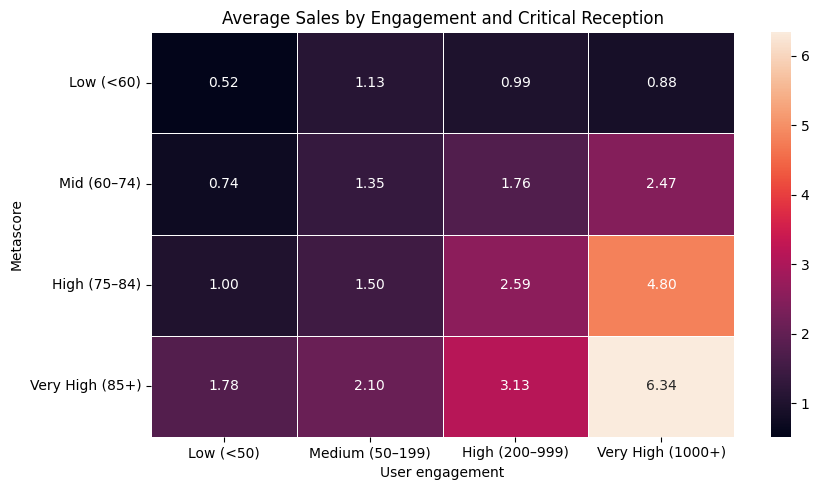

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

query = """
SELECT
    CASE
        WHEN metascore < 60 THEN 'Low (<60)'
        WHEN metascore < 75 THEN 'Mid (60–74)'
        WHEN metascore < 85 THEN 'High (75–84)'
        ELSE 'Very High (85+)'
    END AS score_band,

    CASE
        WHEN user_review_count < 50 THEN 'Low (<50)'
        WHEN user_review_count < 200 THEN 'Medium (50–199)'
        WHEN user_review_count < 1000 THEN 'High (200–999)'
        ELSE 'Very High (1000+)'
    END AS engagement_band,

    AVG(Total_Sales) AS avg_sales

FROM games

GROUP BY score_band, engagement_band;
"""

heatmap_data = pd.read_sql(query, conn)

heatmap = heatmap_data.pivot(
    index="score_band",
    columns="engagement_band",
    values="avg_sales"
)

# Put categories in logical order
heatmap = heatmap.reindex(
    ["Low (<60)", "Mid (60–74)", "High (75–84)", "Very High (85+)"]
)

heatmap = heatmap[
    ["Low (<50)", "Medium (50–199)", "High (200–999)", "Very High (1000+)"]
]

plt.figure(figsize=(9, 5))
sns.heatmap(
    heatmap,
    annot=True,
    fmt=".2f",
    linewidths=0.5
)

plt.xlabel("User engagement")
plt.ylabel("Metascore")
plt.title("Average Sales by Engagement and Critical Reception")
plt.tight_layout()
plt.show()

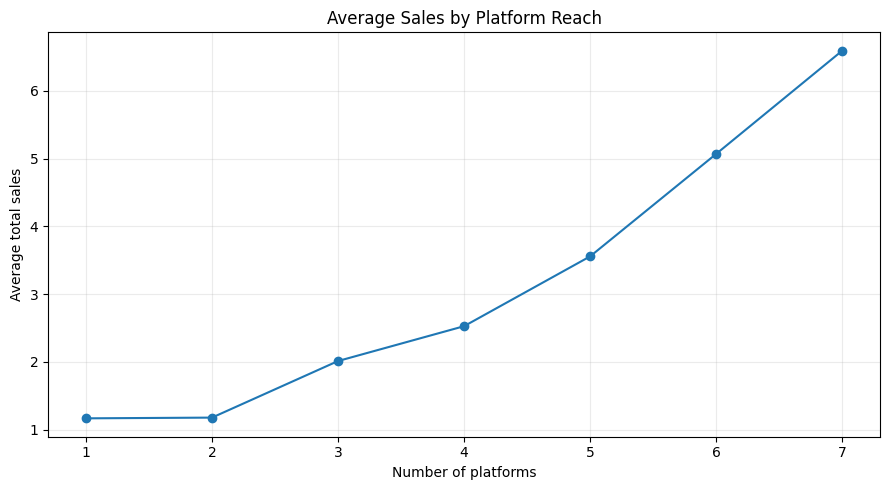

In [ ]:
query = """
SELECT
    platform_count,
    COUNT(*) AS games,
    AVG(Total_Sales) AS avg_sales
FROM games
WHERE platform_count <= 7
GROUP BY platform_count
ORDER BY platform_count;
"""

platform_plot = pd.read_sql(query, conn)

plt.figure(figsize=(9, 5))
plt.plot(
    platform_plot["platform_count"],
    platform_plot["avg_sales"],
    marker="o"
)

plt.xlabel("Number of platforms")
plt.ylabel("Average total sales")
plt.title("Average Sales by Platform Reach")
plt.xticks(platform_plot["platform_count"])
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

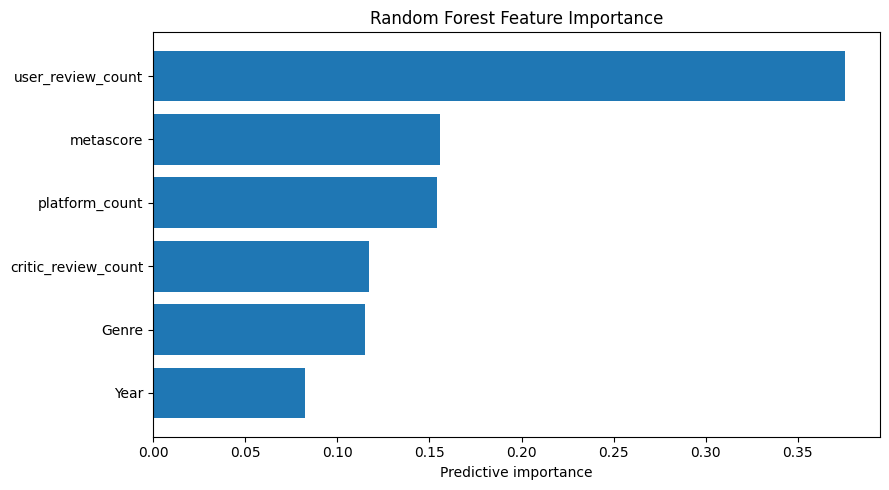

In [ ]:
ml_plot = importance.copy()

ml_plot["Feature"] = ml_plot["Feature"].str.replace(
    "remainder__", "", regex=False
)

ml_plot.loc[
    ml_plot["Feature"].str.startswith("genre__Genre_"),
    "Feature"
] = "Genre"

ml_plot = (
    ml_plot
    .groupby("Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

plt.figure(figsize=(9, 5))

plt.barh(
    ml_plot["Feature"],
    ml_plot["Importance"]
)

plt.xlabel("Predictive importance")
plt.ylabel("")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()